In [ ]:
from typing import *
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import circmean, circstd

In [ ]:
labels = [
    "0-1",
    "1-2",
    "0-2"
]

raw_calibrated = np.array([
    [ # 012
        [0.152873, 0.153741, 0.165066, 0.165681, 0.137697, 0.117028, 0.165398, 0.14656, 0.149018, 0.133581, 0.163869, 0.118732, 0.169452, 0.142756, 0.181272, 0.128998, 0.109196, 0.165967, 0.142659, 0.169697, 0.165312, 0.148947, 0.142089, 0.160119, 0.150698, 0.165095, 0.17084, 0.148626, 0.148711, 0.149666, 0.157196, 0.13589, 0.143504, 0.153589, 0.172538, 0.141044, 0.176621, 0.159841, 0.140273, 0.141202, 0.152099, 0.189528, 0.156328, 0.137109, 0.133277, 0.123301, 0.126281, 0.15639, 0.168388, 0.134338, 0.143279, 0.138506, 0.165559, 0.130132, 0.155329, 0.169605, 0.155221, 0.153973, 0.166565, 0.159515, 0.154947, 0.158732, 0.152038, 0.183753, 0.160746, 0.164828, 0.115864, 0.139889, 0.131531, 0.148199, 0.146803, 0.160013, 0.180963, 0.154415, 0.153155, 0.175262, 0.126748, 0.153517, 0.159314, 0.165603, 0.151095, 0.161957, 0.121368, 0.178732, 0.1488, 0.148982, 0.166788, 0.150838, 0.170117, 0.153197, 0.171821, 0.148726, 0.126526, 0.13265, 0.127283, 0.121804, 0.159625, 0.181607, 0.146696, 0.10974],
        [-0.14403, -0.121277, -0.127158, -0.150101, -0.145767, -0.121822, -0.142889, -0.140208, -0.139726, -0.132834, -0.137241, -0.140934, -0.142796, -0.11276, -0.13274, -0.111747, -0.109953, -0.137491, -0.110712, -0.166758, -0.144618, -0.122584, -0.12502, -0.143819, -0.103224, -0.129082, -0.125705, -0.14289, -0.151989, -0.145567, -0.119555, -0.131642, -0.138453, -0.126942, -0.157812, -0.124618, -0.149453, -0.142568, -0.139304, -0.123993, -0.15325, -0.157853, -0.149078, -0.115611, -0.137603, -0.128268, -0.116658, -0.142327, -0.148044, -0.136224, -0.109794, -0.132536, -0.118422, -0.130829, -0.120091, -0.131858, -0.138121, -0.130069, -0.160264, -0.150458, -0.138752, -0.119159, -0.127862, -0.145714, -0.175091, -0.144014, -0.122243, -0.106146, -0.109255, -0.125126, -0.109621, -0.131663, -0.155361, -0.132107, -0.161102, -0.153147, -0.12498, -0.150654, -0.133299, -0.143347, -0.171888, -0.126308, -0.102794, -0.140708, -0.139135, -0.156833, -0.128528, -0.150285, -0.138415, -0.133864, -0.115357, -0.143357, -0.11976, -0.0886261, -0.142326, -0.131056, -0.121246, -0.13942, -0.139742, -0.111935],
        [0.00885747, 0.0324557, 0.0378613, 0.0155534, -0.00794018, -0.00491529, 0.0225134, 0.00638156, 0.00931198, 0.000754793, 0.0266318, -0.0221371, 0.0266829, 0.0300366, 0.0485144, 0.0171804, -0.000885008, 0.0284834, 0.0319953, 0.0027918, 0.0206956, 0.02637, 0.0170538, 0.0162901, 0.0475347, 0.0359941, 0.0450706, 0.00577705, -0.00318916, 0.00415989, 0.0376125, 0.00424955, 0.00509578, 0.0266413, 0.0146553, 0.0164086, 0.027213, 0.0172736, 0.00101503, 0.0171896, -0.00111349, 0.0317819, 0.00722507, 0.021495, -0.00426673, -0.00503631, 0.00949915, 0.0140603, 0.0203386, -0.00184234, 0.0335577, 0.00597458, 0.0470365, -0.000697544, 0.0352205, 0.0377307, 0.0171024, 0.0239004, 0.00618115, 0.00904355, 0.0162016, 0.0395349, 0.0241699, 0.0381367, -0.0143914, 0.0208061, -0.00650652, 0.0338401, 0.0222673, 0.0230691, 0.0372217, 0.028343, 0.0256528, 0.0223043, -0.00789419, 0.0221166, 0.0017026, 0.00286961, 0.0260138, 0.0222615, -0.0207534, 0.0356155, 0.0185375, 0.0380682, 0.00968189, -0.0077524, 0.0382131, 0.000604197, 0.0317451, 0.0193309, 0.056324, 0.00540666, 0.00664157, 0.0441665, -0.0149304, -0.0092422, 0.0383336, 0.042245, 0.00698953, -0.00234421],
    ],
    [ # 120
        [-0.0735559, -0.0873541, -0.0847786, -0.0703474, -0.0924951, -0.0969067, -0.086018, -0.0689122, -0.0525765, -0.0855738, -0.0870156, -0.100419, -0.122414, -0.103707, -0.0701256, -0.0936402, -0.0854387, -0.0592613, -0.0854919, -0.0745521, -0.0507958, -0.0846773, -0.0943536, -0.101433, -0.0531721, -0.0739829, -0.0734188, -0.0534795, -0.0521296, -0.0791117, -0.0766505, -0.096062, -0.0838156, -0.0634985, -0.0852766, -0.0922989, -0.074938, -0.0713198, -0.0946939, -0.0634828, -0.0639275, -0.0948215, -0.0757128, -0.0896256, -0.11564, -0.0645772, -0.0718685, -0.103057, -0.0740785, -0.0765327, -0.0854244, -0.0560044, -0.0755996, -0.0926872, -0.110401, -0.103821, -0.0719654, -0.09246, -0.0692604, -0.085017, -0.0834354, -0.0531499, -0.101614, -0.0980301, -0.0712778, -0.0982467, -0.0738273, -0.0822799, -0.082828, -0.0934657, -0.104281, -0.0769153, -0.071476, -0.0801947, -0.0929648, -0.0798495, -0.0734794, -0.0929084, -0.0691109, -0.0525857, -0.0727596, -0.0953874, -0.0692643, -0.101803, -0.0977422, -0.0872376, -0.0491945, -0.0976995, -0.0729044, -0.0966604, -0.0816618, -0.063603, -0.0854474, -0.101557, -0.101693, -0.077011, -0.078487, -0.0841938, -0.0747919, -0.0854416],
        [-0.0278218, -0.0422515, -0.0489874, -0.0537913, -0.0245715, -0.0332127, -0.0532178, -0.0491024, -0.0438721, -0.0413842, -0.0432049, -0.0375029, -0.00829783, -0.0370674, -0.0471016, -0.0250668, -0.0489565, -0.0507854, -0.0263584, -0.0324621, -0.0563855, -0.049625, -0.0696351, -0.0441526, -0.0636026, -0.0647583, -0.0388168, -0.0486948, -0.0504301, -0.0365391, -0.0193545, -0.0250579, -0.0491258, -0.0346106, -0.060305, -0.0502897, -0.0331905, -0.0431984, -0.0266341, -0.0587866, -0.0513539, -0.0505091, -0.0315253, -0.0373252, -0.0363334, -0.0354169, -0.0419236, -0.0322644, -0.0544198, -0.0335395, -0.0255421, -0.0429661, -0.0382578, -0.0286818, -0.0312997, -0.0364123, -0.0446211, -0.0307931, -0.0371883, -0.0384813, -0.0293836, -0.0527637, -0.0328542, -0.0725946, -0.0456229, -0.0425903, -0.0603972, -0.0593263, -0.0173647, -0.0332866, -0.0247906, -0.0180642, -0.036879, -0.0404636, -0.0406959, -0.0391261, -0.048895, -0.0428473, -0.0601498, -0.0647641, -0.047678, -0.0312152, -0.0370539, -0.0216768, -0.0329641, -0.0185707, -0.0432243, -0.0486791, -0.0568027, -0.0205573, -0.0427584, -0.058834, -0.0541999, -0.0492536, -0.0450875, -0.0239462, -0.0504881, -0.0210341, -0.0853835, -0.0499775],
        [-0.101475, -0.129606, -0.133753, -0.124139, -0.117025, -0.130167, -0.13919, -0.117997, -0.0964432, -0.12696, -0.13022, -0.137975, -0.130779, -0.14084, -0.117221, -0.118675, -0.134384, -0.109986, -0.111813, -0.107052, -0.107038, -0.134286, -0.163826, -0.145558, -0.116682, -0.138801, -0.112252, -0.102108, -0.10246, -0.115653, -0.096045, -0.12111, -0.132932, -0.0982039, -0.145518, -0.142535, -0.108169, -0.114522, -0.121315, -0.122261, -0.115236, -0.145256, -0.107269, -0.126965, -0.152074, -0.100075, -0.113799, -0.135404, -0.128506, -0.110098, -0.110929, -0.0989665, -0.113866, -0.12137, -0.141845, -0.140324, -0.116586, -0.123259, -0.106487, -0.123502, -0.112814, -0.105792, -0.134563, -0.170506, -0.116893, -0.140841, -0.134271, -0.141603, -0.100176, -0.126767, -0.129132, -0.0949919, -0.108391, -0.120661, -0.133663, -0.118978, -0.122375, -0.135751, -0.1293, -0.117276, -0.120432, -0.126638, -0.106365, -0.123479, -0.130758, -0.105749, -0.0924675, -0.146292, -0.12972, -0.117168, -0.124423, -0.12243, -0.139608, -0.150725, -0.146728, -0.100992, -0.128976, -0.105168, -0.16024, -0.135409],
    ],
    [ # 201
        [-0.00112393, -0.0142423, -0.00242532, -0.0146411, 0.0100965, 0.0328035, 0.0260944, 0.00856503, -0.00131186, -0.000991774, -0.00501092, 0.0125981, -0.0267044, 0.0153337, 0.00753073, 0.0189882, -0.020111, 0.00451452, -0.00491804, 0.0107547, 0.00291781, 0.000935709, 0.0281103, -0.00951463, -0.0223115, 0.0178552, -0.000771908, 0.0333212, -0.0247951, 0.0110025, 0.0217091, -0.00677245, 0.010675, 0.0110354, 0.0198343, 0.0131984, -0.00592439, -0.000349923, 0.0360712, 0.0370448, 0.0242379, -0.0105786, 0.0311833, 0.0143305, 0.0231099, 0.0319333, 0.0108945, 0.0121534, -0.00060623, -0.00567266, 0.0348868, 0.0113154, 0.00681236, -0.00405676, -0.00195615, 0.00542334, 0.025957, 0.0152893, 0.0142232, 0.0180141, 0.00575569, 0.00905341, -0.00653866, 0.0169034, 0.00363368, -0.000909328, 0.000792312, 0.0020471, -0.00885597, 0.0189198, 0.00997426, -0.019846, 0.00383348, -0.0126094, 0.030053, 0.00346372, 0.0204579, 0.00871647, -0.00112542, 0.00372297, 0.00562694, -0.00503225, -0.000674999, 0.0109361, -0.0214509, 0.00723986, 0.0269484, -0.0182258, 0.022472, 0.0205655, 0.0149679, -0.0140028, 0.0128573, 0.00954159, 0.0226649, -0.0400615, 0.0274567, -0.00593997, 0.011239, -0.017809],
        [0.11445, 0.103208, 0.121328, 0.126523, 0.0910298, 0.0941308, 0.103348, 0.0995733, 0.0836338, 0.133223, 0.133391, 0.100343, 0.125802, 0.083148, 0.113798, 0.102032, 0.138215, 0.1047, 0.132273, 0.0877812, 0.110339, 0.108857, 0.0863126, 0.127278, 0.137858, 0.0861941, 0.0931563, 0.0915289, 0.110221, 0.0968203, 0.104505, 0.105449, 0.112412, 0.101242, 0.0810389, 0.125981, 0.103895, 0.125602, 0.0854554, 0.101059, 0.10057, 0.0935717, 0.0950347, 0.129874, 0.116229, 0.0879305, 0.103308, 0.112758, 0.126712, 0.0963164, 0.0729574, 0.106679, 0.121907, 0.097031, 0.125675, 0.126111, 0.0956171, 0.114074, 0.118457, 0.0978302, 0.133452, 0.098634, 0.115938, 0.113915, 0.126011, 0.109892, 0.123371, 0.117075, 0.12659, 0.090813, 0.0912846, 0.119539, 0.104252, 0.115801, 0.106187, 0.131535, 0.106745, 0.0896261, 0.105648, 0.108828, 0.12528, 0.10139, 0.100557, 0.0865309, 0.108472, 0.11689, 0.102107, 0.104046, 0.105997, 0.11121, 0.110294, 0.127571, 0.0717664, 0.0862853, 0.0640751, 0.132153, 0.0811375, 0.129789, 0.114799, 0.112373],
        [0.113312, 0.0890248, 0.118909, 0.111863, 0.101093, 0.12705, 0.129509, 0.108134, 0.0824658, 0.132296, 0.128477, 0.112943, 0.0989352, 0.0984058, 0.121319, 0.121049, 0.118146, 0.109216, 0.127442, 0.0985067, 0.113251, 0.10979, 0.114422, 0.117791, 0.115535, 0.104007, 0.0924633, 0.124959, 0.0854154, 0.107818, 0.126247, 0.098705, 0.123068, 0.112282, 0.100759, 0.139073, 0.098004, 0.125275, 0.12164, 0.138185, 0.124886, 0.0831708, 0.126324, 0.144093, 0.139252, 0.11995, 0.114206, 0.124892, 0.126134, 0.0907381, 0.107767, 0.117997, 0.12871, 0.0930651, 0.123744, 0.131536, 0.121636, 0.129331, 0.132625, 0.115858, 0.139212, 0.107682, 0.109377, 0.130786, 0.129653, 0.108976, 0.124178, 0.119115, 0.117761, 0.10971, 0.101234, 0.0995724, 0.108085, 0.103138, 0.136303, 0.135002, 0.127224, 0.098345, 0.104528, 0.112548, 0.130912, 0.0963952, 0.0999064, 0.0974069, 0.0870115, 0.12412, 0.129127, 0.0859053, 0.128477, 0.131745, 0.125252, 0.113555, 0.0845538, 0.095807, 0.0865919, 0.091943, 0.108525, 0.123913, 0.126019, 0.0945628],
    ]
])

raw_uncalibrated = np.array([
    [ # 012
        [0.590588, 0.907184, -1.20079, -2.22272, 2.54023, 2.96507, 2.43544, -2.24015, -2.16103, 0.834962, -3.00922, 2.31158, -1.01428, -1.43385, -2.59845, -0.61116, -1.52112, -1.72556, -2.68998, -1.01447, -1.07225, -1.50599, -3.00506, 2.09039, -0.983494, -2.2771, -1.82485, -0.721071, 0.955558, 0.118986, 2.16547, 2.46188, -1.37911, 1.77156, -0.173608, -1.45961, 2.10928, -2.93701, -2.69031, -2.6914, 0.592802, -1.72597, 2.48224, -2.95661, 0.0506558, -3.1025, 0.488678, 1.43428, -0.623017, 2.14617, -3.0027, 2.933, -3.03543, 0.966683, 1.09455, -0.172906, -0.712572, 0.517075, -2.14259, 2.64343, 0.201523, -2.38459, 0.986337, 2.50932, 2.09357, -1.80226, -2.73884, 1.31439, 2.06824, -1.58446, -2.23683, 1.70144, 1.72338, 0.937011, 0.828287, 0.564853, -1.3936, 1.93332, 2.174, -2.60947, -0.193787, 2.09481, -1.08409, 1.71928, -1.89493, -0.611037, -1.87852, -1.05586, -1.29574, -0.319517, -0.250635, -1.84272, -1.86484, 0.444367, -1.73344, 2.47456, -2.82835, -3.09664, -1.8447, 0.317726],
        [2.48677, 2.19222, 0.773609, 0.201346, 1.30663, 1.85187, 3.01031, -2.14307, -1.43523, -1.30013, -1.74908, -2.40433, -2.80222, -1.35652, -0.96055, -0.96314, 1.05563, -1.85185, -2.06399, 2.12312, 0.522614, 2.24551, 2.11161, 2.17208, 2.1877, 1.84515, 2.18826, 2.56278, -1.81728, 1.0423, 2.11663, -2.13768, -3.0087, 1.32296, -1.40345, 0.617473, -0.582392, 1.31107, 2.56819, 1.90312, -1.45052, -1.45661, 0.253836, -2.54027, -0.85851, 1.06067, -2.51277, 2.09397, -0.608034, -2.95164, 1.78518, -1.82104, -2.54173, -0.251779, 1.45776, -0.251382, -1.69882, -1.7444, -2.63515, 0.0956497, -1.43651, 2.11627, 0.539157, 3.0066, -0.554969, 0.519049, 1.48538, 1.39478, -0.548454, 1.37804, -0.101324, -1.01211, -0.5911, -0.932952, -1.79823, -0.45469, 1.32481, -0.927353, 0.296507, 2.16859, -0.632002, 1.7947, 0.457634, -2.93123, -1.41118, -2.50221, 1.40158, 0.199925, -2.61616, -0.123212, -2.12355, -2.93343, -2.85978, -0.0799161, 2.93136, 0.195306, 1.40697, -2.82515, -1.98867, -0.337489],
        [3.07737, 3.09939, -0.427232, -2.0214, -2.43619, -1.46637, -0.837432, 1.89999, 2.68694, -0.465162, 1.52489, -0.0926821, 2.46672, -2.79033, 2.72417, -1.57437, -0.465618, 2.70579, 1.52926, 1.1085, -0.549634, 0.739523, -0.893463, -2.02073, 1.20427, -0.431965, 0.363344, 1.84175, -0.861628, 1.16135, -2.00111, 0.324194, 1.89542, 3.09452, -1.57713, -0.842159, 1.52694, -1.62594, -0.122076, -0.788304, -0.857677, 3.10071, 2.73605, 0.786302, -0.807794, -2.0419, -2.02421, -2.75494, -1.23106, -0.805423, -1.21745, 1.11196, 0.705924, 0.714904, 2.5523, -0.424304, -2.41139, -1.22733, 1.50532, 2.73907, -1.23498, -0.26836, 1.52549, -0.767167, 1.53855, -1.28322, -1.25359, 2.70926, 1.51978, -0.206421, -2.33811, 0.689322, 1.13233, 0.00405563, -0.969891, 0.110164, -0.0688532, 1.00597, 2.4705, -0.440875, -0.825751, -2.39371, -0.626495, -1.2119, 2.97709, -3.11315, -0.476979, -0.855886, 2.37133, -0.442731, -2.37433, 1.50707, 1.55844, 0.364593, 1.19804, 2.66988, -1.42143, 0.361462, 2.44985, -0.019913]
    ],
    [ # 120
        [3.06622, -1.31463, -0.610075, -1.58943, -2.10723, 2.57176, -0.112651, -1.66553, 1.88336, -0.819654, -2.46945, -0.466008, -0.436131, 0.680182, 2.67712, 2.63244, -1.39299, 0.596085, -1.28857, -2.7423, 3.06402, -1.68295, -2.86971, 0.658845, 2.30242, 1.07995, 2.67564, 1.7791, -2.09439, 0.599874, 2.04207, 1.57795, -1.21057, 0.250945, -0.871795, 2.91784, 0.737276, -2.37321, 2.57449, -1.2682, -0.324304, -2.84356, 0.261933, -2.47304, 0.642526, -0.770999, 2.72643, -0.497275, 1.57421, 0.708409, -0.89639, 1.17265, 1.12892, -2.86794, -1.02694, -1.75272, 2.31106, -2.18547, -2.50362, -2.5201, -0.42303, 2.95779, 0.211129, 2.67857, 2.70225, 1.4982, 2.64493, 0.625454, 1.87972, -2.1353, 0.208961, 1.0733, -2.42773, 0.429839, 3.09871, 0.572449, 1.8615, 1.34549, -2.95034, 3.11525, -2.06271, 2.64841, -1.77273, 0.708971, 1.83978, 0.698099, 2.95771, 1.83902, -2.43221, -2.95356, -0.109207, -0.485669, -1.73837, -0.891605, 2.64429, 1.17758, 1.80327, -0.900095, 1.46808, -1.52797],
        [-1.66844, -1.28936, 2.86839, 2.23537, -1.27274, 2.38547, 1.02755, -2.05781, -0.480313, -0.948814, -0.427581, 2.22053, -0.995434, -0.107344, -2.07923, -1.24876, -2.00468, -2.00774, -1.64244, 0.99538, 0.685961, -2.8399, -2.52266, -1.65927, 0.207434, -0.448789, 0.282375, -1.61194, 3.04681, 0.678936, 0.330015, -0.647033, -1.6868, 0.75896, 0.264558, -2.0053, -2.32733, -0.952047, -1.59026, 1.07343, 2.09941, 2.18166, -2.84888, 1.15069, 2.66923, 1.72528, -0.555196, 3.04035, 2.99239, 2.20175, -2.03222, 0.62325, 1.09631, 2.6758, 2.28046, 1.14918, 0.304861, 1.93966, 1.64558, 2.27657, -1.72217, 1.91796, -2.43222, 1.40052, -2.10438, -0.871246, 0.631716, 1.86214, -0.137658, 2.72474, -1.97853, 0.724041, 0.625948, -0.424003, -0.163329, 1.09705, -2.10821, 0.358781, 0.734151, -1.67847, -1.10944, 2.54775, 1.14942, 0.667553, 2.33218, -0.927899, -0.0333669, 2.99667, 1.00392, -0.48034, 0.699958, 0.291453, -2.84517, -2.07815, -2.12853, -0.851101, -2.44906, -0.455822, -0.519242, -0.981049],
        [1.39768, -2.60398, 2.25833, 0.645943, 2.90326, -1.326, 0.914949, 2.55987, 1.40306, -1.76847, -2.89703, 1.75447, -1.43163, 0.572772, 0.597896, 1.38371, 2.88554, -1.41159, -2.93097, -1.74696, -2.53307, 1.76035, 0.890973, -1.0004, 2.50995, 0.631103, 2.958, 0.167233, 0.952511, 1.27881, 2.37204, 0.930925, -2.89735, 1.00981, -0.607173, 0.912596, -1.5901, 2.95792, 0.984246, -0.194764, 1.77515, -0.661827, -2.58698, -1.32237, -2.97153, 0.954203, 2.17123, 2.54299, -1.71659, 2.91013, -2.92858, 1.7959, 2.22522, -0.192137, 1.25338, -0.603622, 2.61592, -0.245816, -0.858079, -0.243534, -2.1452, -1.40732, -2.22119, -2.20397, 0.597879, 0.626946, -3.00658, 2.4876, 1.74208, 0.589433, -1.76963, 1.79733, -1.80182, 0.00583268, 2.93538, 1.6695, -0.24671, 1.70427, -2.21623, 1.43685, 3.11104, -1.08707, -0.62336, 1.37653, -2.11128, -0.22974, 2.92429, -1.4474, -1.42829, 2.84933, 0.590748, -0.194209, 1.69968, -2.96967, 0.515811, 0.32645, -0.645795, -1.35586, 0.948777, -2.50901]
    ],
    [ # 201
        [-2.04483, 1.13707, -1.54676, 0.376777, 2.75789, 2.75227, 1.071, 2.75384, -1.9689, -1.57377, -2.10135, 2.34048, 2.69392, -2.42137, 2.41426, -1.97273, 1.57817, 1.60031, 2.71386, 2.33754, -0.41671, -1.46892, 2.77154, -2.52784, -0.442622, -0.796779, -1.70583, -3.13719, -1.0711, 2.33928, -0.345717, -0.820625, 1.57822, -2.86957, -1.63031, -0.852049, 2.71752, -0.393333, 2.78076, -2.05862, 0.129548, 0.775239, 1.46931, -2.63065, -2.04865, 2.38541, 1.73724, 2.68196, -1.46483, -1.99425, -2.73923, 1.84467, 0.375324, -1.7569, -0.0520423, -0.0725496, -0.156, 3.02655, 3.07919, -2.34016, 1.55013, 2.73451, 2.40497, -2.7867, 0.371728, -0.863269, 0.444749, -0.78517, -2.83606, -2.36314, 0.846843, -2.3776, 1.05057, 0.376323, 1.99286, 0.0322649, -1.71053, 0.269412, -0.81265, 0.842953, 1.55055, -1.23614, -1.64971, 3.12855, -1.2244, 1.34282, 0.394144, -0.487447, -1.94363, 0.388172, -2.81359, 0.458708, 2.00258, 1.84275, 0.074053, -2.02866, 1.98779, -2.33453, -2.81803, 0.87135],
        [2.4796, -2.29812, 2.77239, -0.388917, 0.0189718, 1.61844, -2.63812, -2.77055, -2.57616, 0.00932089, 0.534841, -2.69089, -0.311597, -1.08356, 0.38211, -2.29849, 0.431247, -3.08224, 0.873324, -0.297058, 0.668063, -0.0138271, -1.21223, -2.35038, 1.26899, -1.13289, 1.27956, 0.0467746, -0.720998, 2.22672, -3.136, -3.0819, 1.56278, -2.63673, -2.71256, -2.14413, -2.08633, -1.90806, 0.75068, -2.74577, -2.82522, 0.75297, 0.886743, 0.815635, -2.75439, -1.2124, -1.69513, 1.69089, -1.22929, 1.90821, 1.36527, 0.454025, -3.06548, 2.01429, -2.69563, -1.88413, -2.93504, 0.905561, -3.07021, -2.77479, 0.481831, 2.79932, 3.13194, 0.880285, -1.09866, -0.669866, -1.96502, 1.61534, -1.83181, 0.438204, 2.76796, -2.25597, -1.85117, 2.4023, -1.14461, 0.371542, -1.37669, 0.490451, -1.9032, -0.0165411, -1.72647, 2.77899, -3.08849, -1.53066, 0.845746, -2.70465, -3.03589, -1.90699, -0.407001, 0.066213, -0.327514, -1.09716, 1.59696, -0.691566, -0.844224, 1.99584, 2.70963, -1.4879, 0.857001, -0.00917809],
        [0.434751, -1.16099, 1.22563, -0.0121594, 2.77683, -1.91236, -1.56705, -0.0167108, 1.73828, -1.56439, -1.56642, -0.350409, 2.38216, 2.77817, 2.79636, 2.012, 2.00946, -1.48193, -2.69591, 2.04045, 0.251346, -1.48275, 1.5593, 1.40499, 0.82636, -1.92971, -0.426197, -3.0903, -1.79211, -1.71719, 2.80151, 2.38069, 3.14099, 0.776895, 1.9402, -2.99628, 0.631218, -2.30138, -2.75163, 1.47887, -2.6956, 1.52839, 2.35616, -1.81512, 1.48007, 1.17309, 0.0421095, -1.91035, -2.69409, -0.0859423, -1.37404, 2.2987, -2.69016, 0.257483, -2.74765, -1.95668, -3.09098, -2.35111, 0.00891856, 1.16825, 2.03197, -0.74936, -0.746298, -1.90645, -0.726919, -1.53314, -1.52026, 0.830164, 1.61534, -1.92495, -2.66841, 1.6495, -0.800597, 2.77857, 0.848316, 0.40381, -3.0872, 0.759864, -2.71584, 0.826409, -0.175915, 1.54289, 1.54501, 1.59783, -0.378668, -1.36185, -2.64167, -2.39435, -2.35062, 0.454354, -3.14112, -0.638468, -2.68372, 1.15116, -0.770319, -0.0329708, -1.58583, 2.46082, -1.96104, 0.862171]
    ]
])

In [ ]:
calibrated_averaged   = circmean(calibrated,   np.pi, -np.pi, axis=0)
uncalibrated_averaged = circmean(uncalibrated, np.pi, -np.pi, axis=0)


r = lambda x: x#round(x, 4)
men = lambda x: circmean(x, np.pi, -np.pi)
std = lambda x: circstd(x, np.pi, -np.pi)

s = ""
s += '\t'.join([str(r(men(uncalibrated_averaged[i]))) for i in range(3)]) + '\n'
s += '\t'.join([str(r(std(uncalibrated_averaged[i]))) for i in range(3)]) + '\n'
s += '\t'.join([str(r(men(calibrated_averaged  [i]))) for i in range(3)]) + '\n'
s += '\t'.join([str(r(std(calibrated_averaged  [i]))) for i in range(3)]) + '\n'

print(s)

# print('Uncalibrated:')
# for i in range(3):
#     print("Diff", labels[i])
#     print("   ", circmean(uncalibrated_averaged[i], np.pi, -np.pi), "+/-", circstd(uncalibrated_averaged[i], np.pi, -np.pi))

# print('\nCalibrated:')

# for i in range(3):
#     print("Diff", labels[i])
#     print("   ", circmean(calibrated_averaged[i], np.pi, -np.pi), "+/-", circstd(calibrated_averaged[i], np.pi, -np.pi))


-2.4758899685240805	-0.9001827249430159	0.2518458822923355
2.1522828777564182	2.1511253460703323	2.0994990282932973
0.025273641581742723	-0.0227827534002647	0.002616419702219819
0.00956009196140004	0.008855000554752487	0.009279639653883938



In [ ]:
def phaseDiffToEquivalentAntennaDistance(dp):
    c = 3e8 # m/s
    f = 434e6 # Hz
    return (dp*c) / (2*np.pi*f)

dp = 2.1
print(dp, '=', 1000*phaseDiffToEquivalentAntennaDistance(dp), 'mm')

2.1 = 231.03136900436422 mm


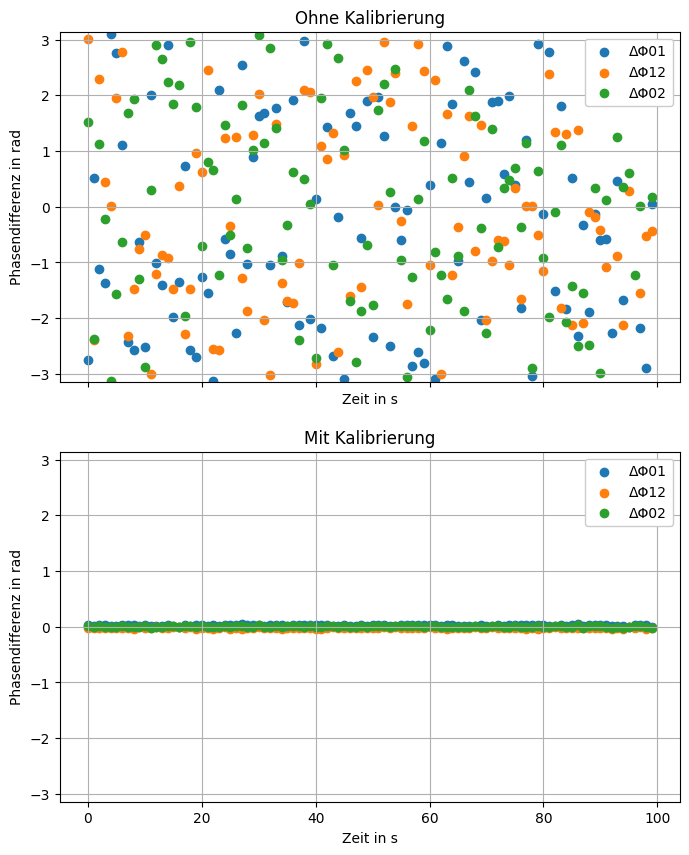

In [ ]:
FIG_SIZE = np.array([8, 5])
fig, axs = plt.subplots(nrows=2, figsize=FIG_SIZE*[1,2], sharex=True, sharey=True)
axs: Iterable[plt.Axes]
ax0, ax1 = axs

X = np.arange(calibrated_averaged.shape[1])

for ax in axs:
    ax.grid()
    ax.set_ylim(-np.pi, np.pi)
    ax.set_ylabel('Phasendifferenz in rad')
    ax.set_xlabel('Zeit in s')


ax0.set_title('Ohne Kalibrierung')
ax0.scatter(X, uncalibrated_averaged[0], label='ΔΦ01')
ax0.scatter(X, uncalibrated_averaged[1], label='ΔΦ12')
ax0.scatter(X, uncalibrated_averaged[2], label='ΔΦ02')
legend0 = ax0.legend()
legend0.get_frame().set_alpha(1)

ax1.set_title('Mit Kalibrierung')
ax1.scatter(X, calibrated_averaged[0], label='ΔΦ01')
ax1.scatter(X, calibrated_averaged[1], label='ΔΦ12')
ax1.scatter(X, calibrated_averaged[2], label='ΔΦ02')
legend1 = ax1.legend(loc='upper right')
legend1.get_frame().set_alpha(1)

fig.savefig('plots/Phasenkohärenz.pdf', bbox_inches='tight')



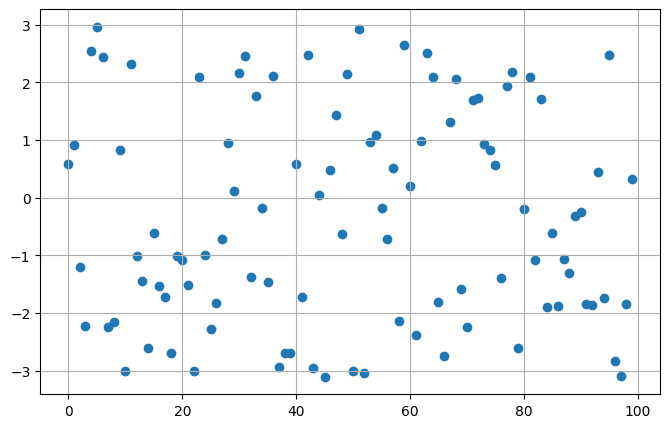

In [ ]:
fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.grid()
ax.scatter(X, raw_uncalibrated[0][0])